# Image-to-image translation

Image-to-image translation it a computer vision taks that consists in tranforming images of one kind into images of a different kind.


Input and output images are usually related. For instance, they may represent the same scene, but under different conditions.

Here are some examples:

![image-to-image translation](https://phillipi.github.io/pix2pix/images/teaser_v3.jpg)

This task can be addressed by using Generative Adversarial Networks (GAN). The main component of a GAN is the "generator" $G$: a neural network that outputs data (e.g., an image). The generator is trained together with another component called the "discriminator" $D$: a binary classifier that distinguishes between  data produced by $G$ and real data from a training set. The two components are trained in parallel and, if the process converges, the generator becomes able to make data that is indistinguishable from the real one.

## Pix2pix

[Pix2pix](https://phillipi.github.io/pix2pix/) is a successful project for image-to-image translation. It uses GANs with two important differences:

- the generator takes as input the image to be translated (in conventional GANs the input is noise);
-  the discriminator output is an average score computed on local patches.

## Project

In this project is an experiment with a variant of pix2pix for the translation of maps into corresponding satellite images.

## Setup and Data

PyTorch as deep learning framework. As training data - a subset of the dataset used in the original paper.

Images have been reduced to $128 \times 128$ pixels, and divided in training and test.

Start by importing all the modules we are going to use, and by copying the data.

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt

URL = "https://drive.google.com/file/d/1bal_0qVK5zJ2kmatkKaHF9kDYXI_vpQB/view?usp=sharing"

!gdown --fuzzy -O- "$URL" | tar xf - && echo OK

Downloading...
From: https://drive.google.com/uc?id=1bal_0qVK5zJ2kmatkKaHF9kDYXI_vpQB
To: <_io.BufferedWriter name='<stdout>'>
100% 17.2M/17.2M [00:00<00:00, 66.8MB/s]
OK


### Dataset class

Each file includes the paired input-output images glued together in a single $256 \times 128$ image (the satellite view on the left, the map on the right). A custom dataset is needed to deal with this kind of data.

![269.jpg](https://camo.githubusercontent.com/fc2b5143a9475d1f982474066e981a5991cf6603b7e528f93af6ef881b9a5fbf/68747470733a2f2f64726976652e676f6f676c652e636f6d2f75633f6578706f72743d766965772669643d314d4d456e666b7a622d62346f455f67776465636370787a6b4751685066566c31)

Pytorch datasets are classes with two main methods:

- `__len__` returns the number of samples;

- `__getitem__` returns one of the samples, given its position in the dataset represented by a numerical index.

The `torchvision` module provides the `torchvision.datasets.ImageFolder` dataset class, which manages images in a folder, divided by class (each class in a different subfolder). We need to modify its `__getitem__` method to return a pair of images instead of the traditional image-class pair.



torch.Size([3, 128, 128]) torch.float32
torch.Size([3, 128, 128]) torch.float32


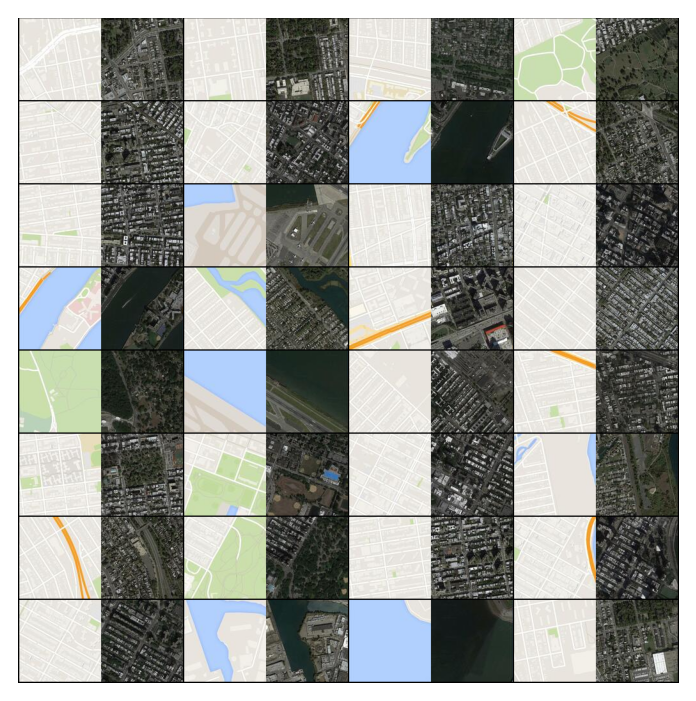

In [ ]:
class PairedDataset(torchvision.datasets.ImageFolder):
    def __getitem__(self, index):
        """Return an input/output pair."""
        image, label = torchvision.datasets.ImageFolder.__getitem__(self, index)
        width = image.shape[2]
        input = image[:, :, (width//2):]
        output = image[:, :, :(width//2)]
        return input, output

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # scale to the [-1, +1] range
])

training_set = PairedDataset("maps128/train", transform=transform)

print(training_set[0][0].shape, training_set[0][0].dtype)
print(training_set[0][1].shape, training_set[0][1].dtype)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True)

def show_batch(*imgs):
    plt.figure(dpi=180)
    imgs = (torch.cat(imgs, -1).detach().cpu() + 1) / 2
    g = torchvision.utils.make_grid(imgs, nrow=4, value_range=(-1, 1))
    plt.imshow(g.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.show()

x, y = next(iter(training_loader))
show_batch(x, y)

## Models

Like traditional GANs, the architecture we will use includes two main modules:
1. the Generator;
2. the Discriminator.

The first transforms the input image into its translation. The second distinguishes between generated and real data.

### Discriminator

The Discriminator is a binary classifier that takes an input-output image pair and estimates the probability that the output image is real rather than artificially generated by the Generator.

Unlike traditional GANs, the Discriminator outputs multiple estimates, one for each of the overlapping "patches" in the images.

It is a rather standard convolutional network composed of a sequence of convolutional blocks (convolution + batch normalization + activation).

The input has six channels (three for the input image and three for the output).
The output has a single channel (the logit of the probability estimate).

In [ ]:
def conv_block(inch, outch, stride):
    """Create a convolutional block.

    It includes:
    - 4x4 Convolution
    - batch normalization
    - Leaky relu
    """
    seq = torch.nn.Sequential(
        torch.nn.Conv2d(inch, outch, kernel_size=4, stride=stride, padding=1),
        torch.nn.BatchNorm2d(outch),
        torch.nn.LeakyReLU(0.2)
    )
    return seq


class Discriminator(torch.nn.Module):
    def __init__(self, features):
        super().__init__()
        # The model starts with 6 channels (3 colors for the 2 input images) and ends with a single channel
        # (the logits for the probability estimates).
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(6, features // 8, kernel_size=4, stride=2, padding=1),
            torch.nn.LeakyReLU(0.2),
            conv_block(features // 8, features // 4, stride=2),
            conv_block(features // 4, features // 2, stride=2),
            conv_block(features // 2, features, stride=1),
            torch.nn.Conv2d(features, 1, kernel_size=4, stride=1, padding=1),
        )

    def forward(self, x, y):
        xy = torch.cat((x, y), 1)
        logits = self.model(xy)
        return logits

DISC_FEATURES = 512
discriminator = Discriminator(DISC_FEATURES)
params = sum(p.numel() for p in discriminator.parameters())
print(f"{params:,d} parameters")

x = torch.zeros(7, 3, 128, 128)
y = torch.zeros(7, 3, 128, 128)
logits = discriminator(x, y)
print(x.shape, "+", y.shape, "->", logits.shape)

2,769,601 parameters
torch.Size([7, 3, 128, 128]) + torch.Size([7, 3, 128, 128]) -> torch.Size([7, 1, 14, 14])


### Generator

The Generator is a convolutional network that takes the input image and translates it into the output domain. The typical architecture is a "U-Net": a sequence of downsampling convolutional blocks followed by a symmetric sequence of upsampling blocks.

![UNet](https://media.licdn.com/dms/image/v2/D4E12AQGZxnk9C8HNmQ/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1714460830241?e=2147483647&v=beta&t=XMv3weswQXqELTdU4pySBLnrB5jVucbSF1cUZScp1qA)

The downsampling blocks extract features at different resolutions, and the upsampling blocks transform them, restoring the original resolution as they do so.

Skip connections connect corresponding downsampling and upsampling blocks to facilitate the reconstruction.

In [ ]:
def downsample_block(inch, outch, batchnorm=True):
    """Create a downsampling block.

    It includes:
    - 4x4 strided Convolution
    - batch normalization (optional)
    - Leaky relu
    """
    seq = torch.nn.Sequential(
        torch.nn.Conv2d(inch, outch, 4, stride=2, padding=1, bias=False),
        torch.nn.LeakyReLU(0.2)
    )
    if batchnorm:
        seq.insert(1, torch.nn.BatchNorm2d(outch))
    return seq

def upsample_block(inch, outch, dropout=True):
    """Create an upsampling block.

    It includes:
    - 4x4 strided transposed Convolution
    - batch normalization
    - Dropout (optional)
    - ReLU
    """
    seq = torch.nn.Sequential(
        torch.nn.ConvTranspose2d(inch, outch, 4, stride=2, padding=1, bias=False),
        torch.nn.BatchNorm2d(outch),
        torch.nn.ReLU()
    )
    if dropout:
        seq.insert(2, torch.nn.Dropout2d())
    return seq

class Generator(torch.nn.Module):
    def __init__(self, features):
        super().__init__()
        # Skip connections make the module non-sequential
        self.down = torch.nn.ModuleList([
            downsample_block(3, features // 8, False),
            downsample_block(features // 8, features // 4),
            downsample_block(features // 4, features // 2),
            downsample_block(features // 2, features),
            downsample_block(features, features),
            downsample_block(features, features),
            downsample_block(features, features)
        ])
        self.up = torch.nn.ModuleList([
            upsample_block(features, features, True),
            upsample_block(features, features, True),
            upsample_block(features, features, True),
            upsample_block(features, features // 2),
            upsample_block(features // 2, features // 4),
            upsample_block(features // 4, features // 8)
        ])
        self.final_conv = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(features // 8, 3, 4, stride=2, padding=1),
            torch.nn.Tanh()
        )

    def forward(self, x):
        skip = []

        x = self.down[0](x)
        for down in self.down[1:]:
            skip.append(x)
            x = down(x)

        x = self.up[0](x)
        for up in self.up[1:]:
            x = x + skip.pop()
            x = up(x)

        x = x + skip.pop()
        x = self.final_conv(x)

        return x

GEN_FEATURES = 256

generator = Generator(GEN_FEATURES)
params = sum(p.numel() for p in generator.parameters())
print(f"{params:,d} parameters")

x = torch.zeros(7, 3, 128, 128)
y = generator(x)
print(x.shape, "->", y.shape)

7,675,203 parameters
torch.Size([7, 3, 128, 128]) -> torch.Size([7, 3, 128, 128])


## Training

The loss function for the pix2pix model combines two terms:

1. a reconstruction loss measuring the difference between the generated image and the ground thruth;

2. an adversarial loss representing how likely is the Discriminator to make the right prediction.  

The Discriminator minimizes only the second term (which is the binary cross-entropy typically used for binary classifiers):

$$\mathcal{L}_D = -\log D(y) - \log (1 - D(G(x))), $$

where $(x, y)$ is a pair of input-output images from the training set, and $D(\cdot)$ is the probability estimated by the discriminator (actually, an average loss is computed because the Discriminator makes multiple estimates).

The Generator optimizes both terms:

$$\mathcal{L}_G = -\log D(G(x)) + \lambda \| y - G(x) \|_1, $$

where $\lambda$ is a tunable coefficient.

In [ ]:
from torch.nn.functional import binary_cross_entropy_with_logits

def discriminator_loss(fake_score, real_score):
    # Implement the discriminator loss...
    real_loss = binary_cross_entropy_with_logits(real_score, torch.ones_like(real_score))
    fake_loss = binary_cross_entropy_with_logits(fake_score, torch.zeros_like(fake_score))
    loss = real_loss + fake_loss
    return loss

def generator_loss(real_images, fake_images, fake_score, lambda_=1.0):
    # Implement the generator loss...
    adv_loss = binary_cross_entropy_with_logits(fake_score, torch.ones_like(fake_score))
    rec_loss = (real_images - fake_images).abs().mean()
    loss = adv_loss + lambda_ * rec_loss

    return loss

loss = discriminator_loss(0.8 * torch.ones(7), 0.2 * torch.ones(7))
print(loss.item())

loss = generator_loss(torch.zeros(7, 3, 128, 128), torch.ones(7, 3, 128, 128), 0.8 * torch.ones(7))
print(loss.item())

1.7692394256591797
1.371100664138794


In [ ]:
device = ("cuda" if torch.cuda.is_available() else "cpu")
generator.to(device)
discriminator.to(device)
print("Device:", device)

Device: cuda


In [ ]:
LR = 1e-3

# We need two separate optimizers.
disc_optimizer = torch.optim.Adam(discriminator.parameters(), LR)
gen_optimizer = torch.optim.Adam(generator.parameters(), LR)

In [ ]:
EPOCHS = 100
LAMBDA = 300.0

totloss = 0.0
steps = 0
for epoch in range(EPOCHS):
    for x, real in training_loader:
        x = x.to(device)
        real = real.to(device)

        if steps % 2 == 0:
            # Optimization step for the generator...
            gen_optimizer.zero_grad()
            fake = generator(x)
            fake_score = discriminator(x, fake)
            gloss = generator_loss(real, fake, fake_score, LAMBDA)
            gloss.backward()
            gen_optimizer.step()

        else:
            # Optimization step for the discriminator...
            disc_optimizer.zero_grad()
            with torch.no_grad():
              fake = generator(x)
            fake_score = discriminator(x, fake)
            real_score = discriminator(x, real)
            dloss = discriminator_loss(fake_score, real_score)
            dloss.backward()
            disc_optimizer.step()

        steps += 1
        if steps % 100 == 0:
            print(f"{steps} [{epoch}]  Disc: {dloss.item():.3f}  Gen: {gloss.item():.3f}")

## Generation

After training, you can feed new images to translate to the Generator.

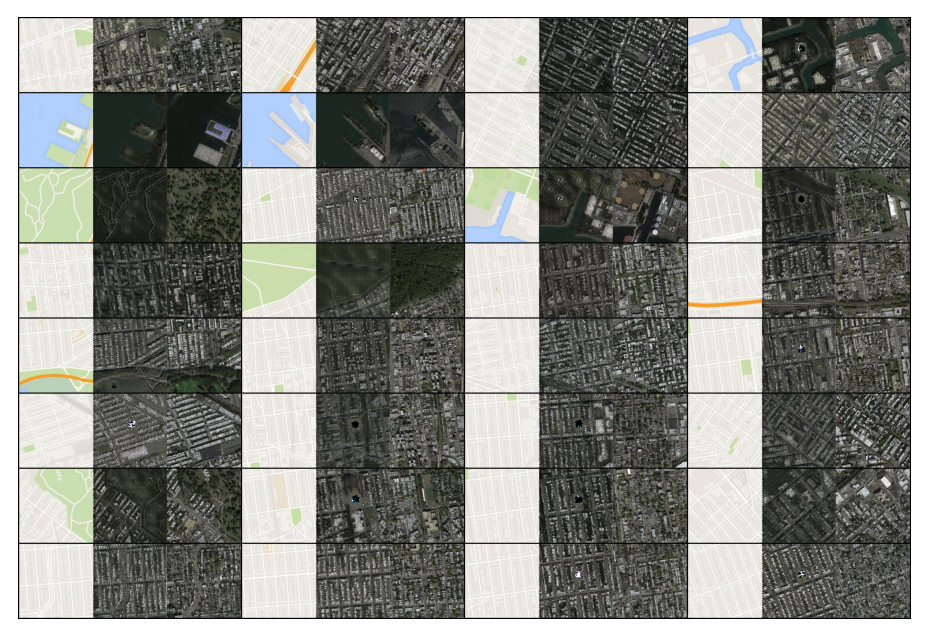

In [ ]:
test_set = PairedDataset("maps128/test", transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

x, y = next(iter(test_loader))
x = x.to(device)
y = y.to(device)

z = generator(x)
show_batch(x, z, y)

### Discriminator's output

To better understand what is happening, let's visualize also the the output from the discriminator. Before you can do that, it must be converted to probability estimates, and must be made uniform to the other images.  

/tmp/ipykernel_2251/3362517931.py:9: UserWarning: `nn.functional.upsample_nearest` is deprecated. Use `nn.functional.interpolate` instead.
  output = torch.nn.functional.upsample_nearest(output, (h, w))


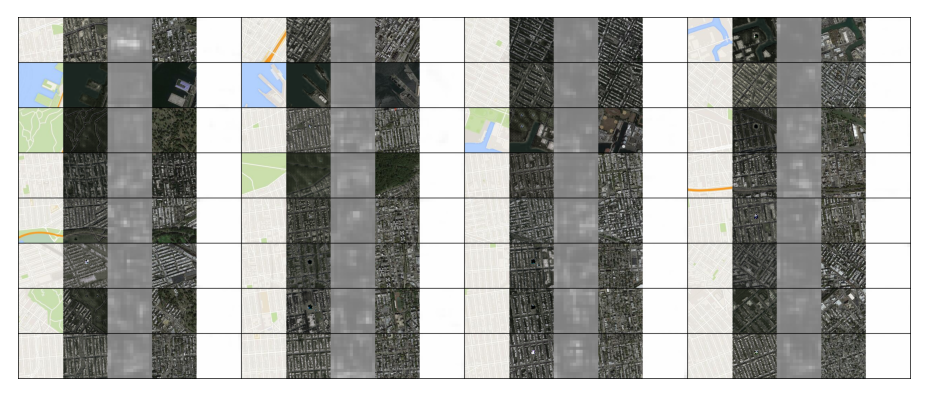

In [ ]:
def discriminator_output(x, z):
    with torch.no_grad():
        # Complete...
        output = discriminator(x, z) # [0, 1, 14, 14] logits
        output = torch.sigmoid(output)
        output = torch.cat([output, output, output], 1)
        h = z.shape[2]
        w = z.shape[3]
        output = torch.nn.functional.upsample_nearest(output, (h, w))

    return output

show_batch(x, z, discriminator_output(x, z), y, discriminator_output(x, y))